<a href="https://colab.research.google.com/github/1234LUCY/hello-word/blob/master/siamese2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# CELL 1: INSTALL REQUIRED PACKAGES
# ============================================================

!pip install pydicom openpyxl scikit-learn matplotlib seaborn torch torchvision xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from sklearn.model_selection import train_test_split, StratifiedKFold  # FIXED: sklearn NOT sklear
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.manifold import TSNE
from scipy import stats
import pydicom
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms
import warnings
warnings.filterwarnings('ignore')

print("✅ All packages installed and imported successfully!")
print(f"PyTorch version: {torch.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 84.7 MB/s eta 0:00:00
✅ All packages installed and imported successfully!
PyTorch version: 2.10.0+cu128


In [3]:
# ============================================================
# CELL 2: MOUNT DRIVE AND LOAD RESPONSE LABELS
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Load Excel labels
excel_path = '/content/drive/My Drive/QIN-BREAST/QIN-Breast_TreatmentResponse2014-12-16 (2).xlsx'
df_labels = pd.read_excel(excel_path)

print("📊 Excel file loaded successfully!")
print(f"Shape: {df_labels.shape}")

# Create response mapping (pCR = Responder, non-pCR = Non-responder)
patient_response = {}
for _, row in df_labels.iterrows():
    patient_id = str(row['Patient ID']).strip()
    response_val = str(row['Response']).strip().upper()

    if response_val == 'PCR':
        patient_response[patient_id] = 1  # Responder
    elif response_val == 'NON-PCR':
        patient_response[patient_id] = 0  # Non-responder

print(f"\n✅ Response mapping:")
print(f"   Total patients: {len(patient_response)}")
print(f"   Responders (pCR): {sum(patient_response.values())}")
print(f"   Non-responders (non-pCR): {len(patient_response) - sum(patient_response.values())}")

Mounted at /content/drive
📊 Excel file loaded successfully!
Shape: (59, 2)

✅ Response mapping:
   Total patients: 59
   Responders (pCR): 20
   Non-responders (non-pCR): 39


In [4]:
# ============================================================
# CELL 3 (FIXED): Load ALL images correctly
# ============================================================

def load_all_modalities(base_path, patient_response, images_per_patient=5):
    """Load images from available modality: Dynamic MRI > PET > CT"""
    base_path = Path(base_path)
    patient_images = defaultdict(list)

    for patient_id in patient_response.keys():
        patient_path = base_path / patient_id
        if not patient_path.exists():
            print(f"   Warning: Patient folder not found: {patient_id}")
            continue

        images_found = False

        # Try Dynamic MRI first
        dynamic_folders = list(patient_path.rglob('*dynamic*'))
        for folder in dynamic_folders:
            if folder.is_dir():
                dcm_files = sorted(folder.glob('*.dcm'))[:images_per_patient]
                for dcm_file in dcm_files:
                    try:
                        ds = pydicom.dcmread(dcm_file)
                        img = ds.pixel_array.astype(np.float32)
                        if img.max() > img.min():
                            img = (img - img.min()) / (img.max() - img.min())
                        img = cv2.resize(img, (224, 224))
                        if len(img.shape) == 2:
                            img = np.stack([img, img, img], axis=-1)
                        patient_images[patient_id].append(img)
                        images_found = True
                    except Exception as e:
                        continue
                if images_found:
                    break

        # If no Dynamic MRI, try PET
        if not images_found:
            pet_folders = list(patient_path.rglob('*PET*'))
            for folder in pet_folders:
                if folder.is_dir() and ('AC' in str(folder)):
                    dcm_files = sorted(folder.glob('*.dcm'))[:images_per_patient]
                    for dcm_file in dcm_files:
                        try:
                            ds = pydicom.dcmread(dcm_file)
                            img = ds.pixel_array.astype(np.float32)
                            if img.max() > img.min():
                                img = (img - img.min()) / (img.max() - img.min())
                            img = cv2.resize(img, (224, 224))
                            if len(img.shape) == 2:
                                img = np.stack([img, img, img], axis=-1)
                            patient_images[patient_id].append(img)
                            images_found = True
                        except:
                            continue
                    if images_found:
                        break

        # If no PET, try CT
        if not images_found:
            ct_folders = list(patient_path.rglob('*CTAC*'))
            for folder in ct_folders:
                if folder.is_dir():
                    dcm_files = sorted(folder.glob('*.dcm'))[:images_per_patient]
                    for dcm_file in dcm_files:
                        try:
                            ds = pydicom.dcmread(dcm_file)
                            img = ds.pixel_array.astype(np.float32)
                            if img.max() > img.min():
                                img = (img - img.min()) / (img.max() - img.min())
                            img = cv2.resize(img, (224, 224))
                            if len(img.shape) == 2:
                                img = np.stack([img, img, img], axis=-1)
                            patient_images[patient_id].append(img)
                            images_found = True
                        except:
                            continue
                    if images_found:
                        break

        if not images_found:
            print(f"   Warning: No images found for {patient_id}")

    return patient_images

print("🔍 Loading ALL modalities (Dynamic MRI + PET + CT)...")
base_path = '/content/drive/My Drive/QIN-BREAST'
patient_images = load_all_modalities(base_path, patient_response)

print(f"\n✅ Found images for {len(patient_images)} patients")

# Count total images
total_images = sum(len(imgs) for imgs in patient_images.values())
print(f"   Total images loaded: {total_images}")

# Show distribution
responders_found = sum(1 for pid in patient_images if patient_response.get(pid, -1) == 1)
print(f"   Responders with images: {responders_found}")
print(f"   Non-responders with images: {len(patient_images) - responders_found}")

# List which patients are missing
missing_patients = set(patient_response.keys()) - set(patient_images.keys())
if missing_patients:
    print(f"\n⚠️ Missing {len(missing_patients)} patients (no usable images):")
    for pid in list(missing_patients)[:5]:
        print(f"   {pid}")

🔍 Loading ALL modalities (Dynamic MRI + PET + CT)...

✅ Found images for 59 patients
   Total images loaded: 295
   Responders with images: 20
   Non-responders with images: 39


In [5]:
# ============================================================
# CELL 4: EXTRACT SHAPE, TEXTURE, VASCULARITY, INTENSITY BIOMARKERS
# ============================================================

def extract_shape_biomarkers(img):
    # Convert to grayscale if needed
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img

    threshold = img_gray.mean() + 0.5 * img_gray.std()
    tumor_mask = (img_gray > threshold).astype(np.uint8) * 255

    kernel = np.ones((3,3), np.uint8)
    tumor_mask = cv2.morphologyEx(tumor_mask, cv2.MORPH_OPEN, kernel)
    tumor_mask = cv2.morphologyEx(tumor_mask, cv2.MORPH_CLOSE, kernel)

    if tumor_mask.sum() < 100:
        tumor_mask = np.ones_like(img_gray, dtype=np.uint8) * 255

    contours, _ = cv2.findContours(tumor_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest_contour)
        perimeter = cv2.arcLength(largest_contour, True)
        circularity = 4 * np.pi * area / (perimeter * perimeter) if perimeter > 0 else 0
        hull = cv2.convexHull(largest_contour)
        hull_area = cv2.contourArea(hull)
        convexity = area / hull_area if hull_area > 0 else 0
        x, y, w, h = cv2.boundingRect(largest_contour)
        aspect_ratio = w / h if h > 0 else 1
        irregularity = (perimeter * perimeter) / (4 * np.pi * area) - 1 if area > 0 else 0
    else:
        circularity, convexity, aspect_ratio, irregularity = 0.5, 0.5, 1, 0

    return {
        'shape_circularity': circularity,
        'shape_convexity': convexity,
        'shape_aspect_ratio': aspect_ratio,
        'shape_irregularity': irregularity
    }

def extract_texture_biomarkers(img):
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img

    if img_gray.max() > img_gray.min():
        img_norm = ((img_gray - img_gray.min()) / (img_gray.max() - img_gray.min()) * 255).astype(np.uint8)
    else:
        img_norm = img_gray.astype(np.uint8)

    contrast = np.mean(np.abs(np.diff(img_norm, axis=0))) + np.mean(np.abs(np.diff(img_norm, axis=1)))
    homogeneity = 1 / (1 + contrast/255)
    energy = np.mean(img_norm ** 2) / (255**2)
    hist, _ = np.histogram(img_norm, bins=32, density=True)
    hist = hist[hist > 0]
    entropy = -np.sum(hist * np.log2(hist)) if len(hist) > 0 else 0

    from scipy.ndimage import generic_filter
    local_range = generic_filter(img_gray, lambda x: x.max() - x.min(), size=3)
    roughness = np.mean(local_range)

    return {
        'texture_contrast': contrast,
        'texture_homogeneity': homogeneity,
        'texture_energy': energy,
        'texture_entropy': entropy,
        'texture_roughness': roughness
    }

def extract_vascularity_biomarkers(img):
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img

    from scipy.ndimage import sobel
    edges = sobel(img_gray)
    edge_density = np.mean(edges > np.percentile(edges, 75))

    grad_x = np.gradient(img_gray)
    grad_y = np.gradient(img_gray)
    grad_magnitude = np.sqrt(grad_x[0]**2 + grad_y[0]**2)
    mean_gradient = np.mean(grad_magnitude)
    max_gradient = np.max(grad_magnitude)

    hot_spot_threshold = img_gray.mean() + img_gray.std()
    hot_spot_fraction = np.mean(img_gray > hot_spot_threshold)
    grad_heterogeneity = np.std(grad_magnitude) / (np.mean(grad_magnitude) + 1e-8)

    return {
        'vascularity_edge_density': edge_density,
        'vascularity_mean_gradient': mean_gradient,
        'vascularity_max_gradient': max_gradient,
        'vascularity_hot_spot_fraction': hot_spot_fraction,
        'vascularity_tortuosity': grad_heterogeneity
    }

def extract_intensity_patterns(img):
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img

    if img_gray.max() > img_gray.min():
        img_norm = (img_gray - img_gray.min()) / (img_gray.max() - img_gray.min())
    else:
        img_norm = img_gray

    mean_intensity = np.mean(img_norm)
    std_intensity = np.std(img_norm)
    skewness = stats.skew(img_norm.flatten())
    kurtosis = stats.kurtosis(img_norm.flatten())
    p10, p25, p50, p75, p90 = np.percentile(img_norm, [10, 25, 50, 75, 90])
    coefficient_variation = std_intensity / (mean_intensity + 1e-8)
    interquartile_range = p75 - p25
    intensity_range = p90 - p10
    enhancement_ratio = p90 / (p10 + 1e-8)

    return {
        'intensity_mean': mean_intensity,
        'intensity_std': std_intensity,
        'intensity_skewness': skewness,
        'intensity_kurtosis': kurtosis,
        'intensity_cv': coefficient_variation,
        'intensity_iqr': interquartile_range,
        'intensity_range': intensity_range,
        'intensity_enhancement_ratio': enhancement_ratio
    }

print("✅ 4 biomarker categories defined: SHAPE, TEXTURE, VASCULARITY, INTENSITY")

# Extract biomarkers for all patients
all_biomarkers = []

for patient_id, images in patient_images.items():
    if not images or patient_id not in patient_response:
        continue

    shape_features, texture_features, vascularity_features, intensity_features = [], [], [], []

    for img in images:
        try:
            shape_features.append(extract_shape_biomarkers(img))
            texture_features.append(extract_texture_biomarkers(img))
            vascularity_features.append(extract_vascularity_biomarkers(img))
            intensity_features.append(extract_intensity_patterns(img))
        except Exception as e:
            continue

    if shape_features:
        patient_biomarkers = {'patient_id': patient_id, 'response': patient_response[patient_id]}

        for key in shape_features[0].keys():
            patient_biomarkers[key] = np.mean([f[key] for f in shape_features])
        for key in texture_features[0].keys():
            patient_biomarkers[key] = np.mean([f[key] for f in texture_features])
        for key in vascularity_features[0].keys():
            patient_biomarkers[key] = np.mean([f[key] for f in vascularity_features])
        for key in intensity_features[0].keys():
            patient_biomarkers[key] = np.mean([f[key] for f in intensity_features])

        all_biomarkers.append(patient_biomarkers)

df_biomarkers = pd.DataFrame(all_biomarkers)

print(f"\n✅ Extracted biomarkers for {len(df_biomarkers)} patients")
print(f"\n📊 BIOMARKER CATEGORIES:")
print(f"   SHAPE: 4 biomarkers")
print(f"   TEXTURE: 5 biomarkers")
print(f"   VASCULARITY: 5 biomarkers")
print(f"   INTENSITY: 8 biomarkers")
print(f"   TOTAL: 22 biomarkers")

✅ 4 biomarker categories defined: SHAPE, TEXTURE, VASCULARITY, INTENSITY

✅ Extracted biomarkers for 59 patients

📊 BIOMARKER CATEGORIES:
   SHAPE: 4 biomarkers
   TEXTURE: 5 biomarkers
   VASCULARITY: 5 biomarkers
   INTENSITY: 8 biomarkers
   TOTAL: 22 biomarkers


In [6]:
# ============================================================
# CELL 5: PREPARE IMAGES FOR TRANSFER LEARNING MODELS
# ============================================================

# Collect all images into arrays
all_images = []
all_labels = []
all_patient_ids = []

for patient_id, images in patient_images.items():
    if patient_id in patient_response:
        for img in images:
            all_images.append(img)
            all_labels.append(patient_response[patient_id])
            all_patient_ids.append(patient_id)

all_images = np.array(all_images)
all_labels = np.array(all_labels)

print(f"Total images: {len(all_images)}")
print(f"Responder images: {np.sum(all_labels)}")
print(f"Non-responder images: {len(all_labels) - np.sum(all_labels)}")

# Image preprocessing for pre-trained models
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

Total images: 295
Responder images: 100
Non-responder images: 195


In [7]:
# ============================================================
# CELL 6: LOAD 5 PRE-TRAINED MODELS AND EXTRACT FEATURES
# ============================================================
# ============================================================
# CELL 6: LOAD 5 PRE-TRAINED MODELS AND EXTRACT FEATURES (FIXED)
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def extract_features_from_model(model, images, model_name, batch_size=16):
    """Extract features from a pre-trained model with proper handling"""
    model = model.to(device)
    model.eval()

    all_features = []

    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch_images = images[i:i+batch_size]
            batch_tensors = []

            for img in batch_images:
                # Convert and preprocess image
                if img.max() <= 1.0:
                    img = (img * 255).astype(np.uint8)

                # Apply transforms
                img_tensor = transform(img).unsqueeze(0)
                batch_tensors.append(img_tensor)

            if batch_tensors:
                batch = torch.cat(batch_tensors, dim=0).to(device)

                # Forward pass through model
                if model_name == 'ViT-Base':
                    features = model(batch)
                else:
                    features = model(batch)
                    # Flatten features
                    if len(features.shape) > 2:
                        features = features.view(features.size(0), -1)

                all_features.append(features.cpu().numpy())

    if len(all_features) == 0:
        return np.array([])

    return np.vstack(all_features)

def create_feature_extractor(model_name):
    """Create a feature extractor for each model type"""

    if model_name == 'ResNet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        # Remove the classification head
        model = nn.Sequential(*list(model.children())[:-1])
        return model

    elif model_name == 'EfficientNetB0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        # Remove classification head
        model = nn.Sequential(*list(model.children())[:-1])
        return model

    elif model_name == 'DenseNet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        # DenseNet has features attribute
        return model.features

    elif model_name == 'ViT-Base':
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        # Remove classification head
        model.heads = nn.Identity()
        return model

    elif model_name == 'InceptionV3':
        model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        # Remove classification head
        model = nn.Sequential(*list(model.children())[:-1])
        # Inception expects 299x299
        return model

    return None

# Load models
print("📦 Loading 5 pre-trained models...")
model_names = ['ResNet50', 'EfficientNetB0', 'DenseNet121', 'ViT-Base', 'InceptionV3']
models_dict = {}
all_features = {}
model_performance = {}

for name in model_names:
    try:
        print(f"\n🔍 Loading {name}...")
        model = create_feature_extractor(name)
        if model is not None:
            models_dict[name] = model
            print(f"   ✅ Loaded successfully")
        else:
            print(f"   ❌ Failed to load")
    except Exception as e:
        print(f"   ❌ Error loading {name}: {e}")

print(f"\n✅ Successfully loaded {len(models_dict)} models")

# Extract features from each model
print("\n" + "="*70)
print("EXTRACTING FEATURES FROM MODELS")
print("="*70)

for model_name, model in models_dict.items():
    print(f"\n🔍 Processing {model_name}...")
    try:
        features = extract_features_from_model(model, all_images, model_name)
        all_features[model_name] = features
        print(f"   Feature dimension: {features.shape}")

        # Quick evaluation with Random Forest
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.model_selection import cross_val_score

        # Use a small subset for quick evaluation
        from sklearn.model_selection import train_test_split
        X_train, X_test, y_train, y_test = train_test_split(
            features, all_labels, test_size=0.3, random_state=42, stratify=all_labels
        )

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        rf.fit(X_train_scaled, y_train)
        y_pred = rf.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)

        if len(np.unique(y_test)) > 1:
            auc = roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:, 1])
        else:
            auc = 0.5

        model_performance[model_name] = {'accuracy': acc, 'auc': auc, 'features': features}
        print(f"   Accuracy: {acc:.4f} ({acc*100:.1f}%)")
        print(f"   AUC-ROC:  {auc:.4f}")

    except Exception as e:
        print(f"   ❌ Error: {e}")
        import traceback
        traceback.print_exc()

# Display results
print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY")
print("="*70)

if len(model_performance) > 0:
    for name, perf in model_performance.items():
        print(f"   {name:15s} | Accuracy: {perf['accuracy']:.4f} | AUC: {perf['auc']:.4f}")

    # Find best model
    best_model_name = max(model_performance, key=lambda x: model_performance[x]['accuracy'])
    print(f"\n🏆 BEST MODEL: {best_model_name}")
    print(f"   Accuracy: {model_performance[best_model_name]['accuracy']:.4f}")
    print(f"   AUC-ROC:  {model_performance[best_model_name]['auc']:.4f}")

    # Use best model features for the rest of the pipeline
    best_features = model_performance[best_model_name]['features']
    print(f"   Feature dimension: {best_features.shape}")

else:
    print("⚠️ No models successfully extracted features")
    print("Using DenseNet121 as fallback (creating dummy features for demonstration)")

    # Fallback: create dummy features (for demonstration)
    # This should not happen in production
    best_model_name = "DenseNet121"
    best_features = np.random.randn(len(all_images), 1024)
    model_performance[best_model_name] = {'accuracy': 0.75, 'auc': 0.80, 'features': best_features}

Using device: cuda
📦 Loading 5 pre-trained models...

🔍 Loading ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 232MB/s]


   ✅ Loaded successfully

🔍 Loading EfficientNetB0...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 227MB/s]


   ✅ Loaded successfully

🔍 Loading DenseNet121...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


...

100%|██████████| 330M/330M [00:01<00:00, 210MB/s]


   ✅ Loaded successfully

🔍 Loading InceptionV3...
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 231MB/s] 


   ✅ Loaded successfully

✅ Successfully loaded 5 models

EXTRACTING FEATURES FROM MODELS

🔍 Processing ResNet50...
   Feature dimension: (295, 2048)
   Accuracy: 0.8202 (82.0%)
   AUC-ROC:  0.8867

🔍 Processing EfficientNetB0...
   Feature dimension: (295, 1280)
   Accuracy: 0.7640 (76.4%)
   AUC-ROC:  0.8904

🔍 Processing DenseNet121...
   Feature dimension: (295, 50176)
   Accuracy: 0.9213 (92.1%)
   AUC-ROC:  0.9822

🔍 Processing ViT-Base...
   Feature dimension: (295, 768)
   Accuracy: 0.7416 (74.2%)
   AUC-ROC:  0.7977

🔍 Processing InceptionV3...
   ❌ Error: Calculated padded input size per channel: (3 x 3). Kernel size: (5 x 5). Kernel size can't be greater than actual input size

MODEL PERFORMANCE SUMMARY
   ResNet50        | Accuracy: 0.8202 | AUC: 0.8867
   EfficientNetB0  | Accuracy: 0.7640 | AUC: 0.8904
   DenseNet121     | Accuracy: 0.9213 | AUC: 0.9822
   ViT-Base        | Accuracy: 0.7416 | AUC: 0.7977

🏆 BEST MODEL: DenseNet121
   Accuracy: 0.9213
   AUC-ROC:  0.9822
 

Traceback (most recent call last):
  File "/tmp/ipykernel_1208/2069013860.py", line 115, in <cell line: 0>
    features = extract_features_from_model(model, all_images, model_name)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_1208/2069013860.py", line 39, in extract_features_from_model
    features = model(batch)
               ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1787, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/container.py", line 253, in forward
    input = module(input)
            ^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/modul

In [8]:
# ============================================================
# CELL 7: USE DENSENET121 AS BEST MODEL & AGGREGATE FEATURES
# ============================================================

import os  # ADD THIS LINE
from collections import defaultdict
import joblib

# DenseNet121 is the best model
best_model_name = "DenseNet121"
best_accuracy = 0.9213
best_auc = 0.9822
best_features = model_performance['DenseNet121']['features']

print("="*70)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   Image-level Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.1f}%)")
print(f"   Image-level AUC-ROC:  {best_auc:.4f}")
print(f"   Feature dimension: {best_features.shape}")
print("="*70)

# ============================================================
# AGGREGATE FEATURES BY PATIENT (Average across images)
# ============================================================

# Group features by patient
patient_features = defaultdict(list)

for i, patient_id in enumerate(all_patient_ids):
    patient_features[patient_id].append(best_features[i])

# Create patient-level feature matrix
X_patient = []
y_patient = []
patient_ids_list = []

for patient_id, feats in patient_features.items():
    if patient_id in patient_response:
        X_patient.append(np.mean(feats, axis=0))  # Average across images
        y_patient.append(patient_response[patient_id])
        patient_ids_list.append(patient_id)

X_patient = np.array(X_patient)
y_patient = np.array(y_patient)

print(f"\n📊 Patient-level features:")
print(f"   Shape: {X_patient.shape}")
print(f"   Responders: {np.sum(y_patient)}")
print(f"   Non-responders: {len(y_patient) - np.sum(y_patient)}")

# ============================================================
# APPLY PCA FOR DIMENSIONALITY REDUCTION
# ============================================================

from sklearn.decomposition import PCA

# Reduce 50176 dimensions to something manageable
n_components = min(50, X_patient.shape[0])  # Use 50 components or less
pca = PCA(n_components=n_components, random_state=42)
X_patient_pca = pca.fit_transform(X_patient)

print(f"\n📊 After PCA ({n_components} components):")
print(f"   Shape: {X_patient_pca.shape}")
print(f"   Explained variance ratio: {pca.explained_variance_ratio_.sum():.3f}")

# ============================================================
# SAVE TO DRIVE
# ============================================================

SAVE_PATH = '/content/drive/MyDrive/QIN_BREAST_FINAL/'
os.makedirs(SAVE_PATH, exist_ok=True)

# Save features
np.save(SAVE_PATH + 'X_patient_features.npy', X_patient)
np.save(SAVE_PATH + 'X_patient_pca.npy', X_patient_pca)
np.save(SAVE_PATH + 'y_patient_labels.npy', y_patient)

# Save PCA transformer
joblib.dump(pca, SAVE_PATH + 'pca_transformer.pkl')

print(f"\n💾 Saved to: {SAVE_PATH}")
print(f"   • X_patient_features.npy (original: {X_patient.shape})")
print(f"   • X_patient_pca.npy (reduced: {X_patient_pca.shape})")
print(f"   • y_patient_labels.npy ({y_patient.shape})")
print(f"   • pca_transformer.pkl")

# Show sample of what we have
print(f"\n📋 Sample patient data:")
df_sample = pd.DataFrame({
    'Patient ID': patient_ids_list[:5],
    'Response': y_patient[:5],
    'Features_PCA_1': X_patient_pca[:5, 0],
    'Features_PCA_2': X_patient_pca[:5, 1]
})
print(df_sample.to_string(index=False))

🏆 BEST MODEL: DenseNet121
   Image-level Accuracy: 0.9213 (92.1%)
   Image-level AUC-ROC:  0.9822
   Feature dimension: (295, 50176)

📊 Patient-level features:
   Shape: (59, 50176)
   Responders: 20
   Non-responders: 39

📊 After PCA (50 components):
   Shape: (59, 50)
   Explained variance ratio: 0.988

💾 Saved to: /content/drive/MyDrive/QIN_BREAST_FINAL/
   • X_patient_features.npy (original: (59, 50176))
   • X_patient_pca.npy (reduced: (59, 50))
   • y_patient_labels.npy ((59,))
   • pca_transformer.pkl

📋 Sample patient data:
        Patient ID  Response  Features_PCA_1  Features_PCA_2
QIN-BREAST-01-0001         0      150.475403       -2.095288
QIN-BREAST-01-0002         0      181.796188       -7.535988
QIN-BREAST-01-0003         0     -109.627365      -77.788811
QIN-BREAST-01-0004         0      139.647583        5.831531
QIN-BREAST-01-0005         0      187.629150       -7.369635


In [9]:
# ============================================================
# CELL 8: DEFINE YOUR OPTIMIZED SIAMESE NETWORK
# ============================================================

class OptimizedSiamese(nn.Module):
    """
    YOUR OPTIMIZED SIAMESE NETWORK
    - 4 layers with BatchNorm and Dropout
    - L2 normalization
    - Uncertainty quantification head
    """
    def __init__(self, input_dim, embedding_dim=32):
        super(OptimizedSiamese, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )

        self.uncertainty_head = nn.Sequential(
            nn.Linear(embedding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, embedding_dim),
            nn.Softplus()
        )

    def forward(self, x1, x2):
        emb1 = self.encoder(x1)
        emb2 = self.encoder(x2)

        # L2 normalization
        emb1 = emb1 / (torch.norm(emb1, dim=1, keepdim=True) + 1e-8)
        emb2 = emb2 / (torch.norm(emb2, dim=1, keepdim=True) + 1e-8)

        distance = torch.sqrt(torch.sum((emb1 - emb2) ** 2, dim=1) + 1e-8)

        unc1 = self.uncertainty_head(emb1)
        unc2 = self.uncertainty_head(emb2)
        uncertainty = unc1 + unc2

        return distance, emb1, emb2, uncertainty

class OptimizedContrastiveLoss(nn.Module):
    """Adaptive margin + distance weighting for class imbalance"""
    def __init__(self, base_margin=1.0, n_responders=20, n_nonresponders=39):
        super(OptimizedContrastiveLoss, self).__init__()
        self.base_margin = base_margin
        self.imbalance_ratio = n_nonresponders / n_responders

    def forward(self, distance, label):
        adaptive_margin = self.base_margin * (1 + 0.5 * self.imbalance_ratio)

        margins = torch.where(label == 1,
                              torch.ones_like(label) * adaptive_margin,
                              torch.ones_like(label) * self.base_margin)

        weight = 1.0 / (distance + 0.1)

        loss_pos = label * weight * (distance ** 2)
        loss_neg = (1 - label) * weight * torch.relu(margins - distance) ** 2

        return torch.mean(loss_pos + loss_neg)

print("✅ Optimized Siamese network defined")

✅ Optimized Siamese network defined


In [10]:
# ============================================================
# CELL 9: THREE-MODEL COMPARISON (FIXED)
# Standard Siamese vs Optimized Siamese vs CNN
# ============================================================

print("="*70)
print("THREE-MODEL COMPARISON")
print("Standard Siamese vs Optimized Siamese vs CNN")
print("="*70)

# Use the PCA features from Cell 7
X_data = X_patient_pca  # 59 patients × 50 features
y_data = y_patient

print(f"Data shape: {X_data.shape}")
print(f"Responders: {np.sum(y_data)}, Non-responders: {len(y_data) - np.sum(y_data)}")

# ============================================================
# MODEL DEFINITIONS
# ============================================================

# 1. Standard Siamese (no innovations)
class StandardSiameseSimple(nn.Module):
    def __init__(self, input_dim, embedding_dim=32):
        super(StandardSiameseSimple, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, embedding_dim)
        )

    def forward(self, x1, x2):
        emb1 = self.encoder(x1)
        emb2 = self.encoder(x2)
        distance = torch.sqrt(torch.sum((emb1 - emb2) ** 2, dim=1) + 1e-8)
        return distance, emb1, emb2

# 2. Optimized Siamese (YOUR innovations)
class OptimizedSiameseSimple(nn.Module):
    def __init__(self, input_dim, embedding_dim=32):
        super(OptimizedSiameseSimple, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, embedding_dim),
            nn.LayerNorm(embedding_dim)
        )

        self.uncertainty_head = nn.Sequential(
            nn.Linear(embedding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, embedding_dim),
            nn.Softplus()
        )

    def forward(self, x1, x2):
        emb1 = self.encoder(x1)
        emb2 = self.encoder(x2)
        emb1 = emb1 / (torch.norm(emb1, dim=1, keepdim=True) + 1e-8)
        emb2 = emb2 / (torch.norm(emb2, dim=1, keepdim=True) + 1e-8)
        distance = torch.sqrt(torch.sum((emb1 - emb2) ** 2, dim=1) + 1e-8)
        unc1 = self.uncertainty_head(emb1)
        unc2 = self.uncertainty_head(emb2)
        uncertainty = unc1 + unc2
        return distance, emb1, emb2, uncertainty

# 3. CNN (Baseline) - FIXED
class SimpleCNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        output = self.classifier(x)
        return output.squeeze()  # FIXED: returns (batch_size,)

class ContrastiveLossSimple(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLossSimple, self).__init__()
        self.margin = margin
    def forward(self, distance, label):
        loss_pos = label * (distance ** 2)
        loss_neg = (1 - label) * torch.relu(self.margin - distance) ** 2
        return torch.mean(loss_pos + loss_neg)

# ============================================================
# DATASET CLASSES
# ============================================================

class PairDataset(Dataset):
    def __init__(self, pairs, labels, X):
        self.pairs = pairs
        self.labels = labels
        self.X = X
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        i, j = self.pairs[idx]
        return (torch.FloatTensor(self.X[i]),
                torch.FloatTensor(self.X[j]),
                torch.FloatTensor([self.labels[idx]]))

class CNNDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return (torch.FloatTensor(self.X[idx]),
                torch.FloatTensor([self.y[idx]]))

# ============================================================
# TRAINING FUNCTIONS
# ============================================================

def train_siamese(model, train_loader, optimizer, criterion, epochs=30):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in train_loader:
            x1, x2, label = batch
            x1, x2, label = x1.to(device), x2.to(device), label.squeeze().to(device)
            optimizer.zero_grad()
            if isinstance(model, OptimizedSiameseSimple):
                distance, _, _, _ = model(x1, x2)
            else:
                distance, _, _ = model(x1, x2)
            loss = criterion(distance, label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 15 == 0:
            print(f"  Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

def train_cnn(model, train_loader, val_loader, epochs=50):
    """Train CNN - FIXED shape handling"""
    model.train()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    best_val_acc = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            x, y = batch
            x, y = x.to(device), y.to(device)
            y = y.squeeze()  # FIXED: ensure shape matches

            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Validation
        model.eval()
        all_preds = []
        all_labels = []
        all_probs = []

        with torch.no_grad():
            for batch in val_loader:
                x, y = batch
                x, y = x.to(device), y.to(device)
                y = y.squeeze()

                output = model(x)
                pred = (output > 0.5).float()

                all_preds.extend(pred.cpu().numpy())
                all_labels.extend(y.cpu().numpy())
                all_probs.extend(output.cpu().numpy())

        val_acc = accuracy_score(all_labels, all_preds)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        scheduler.step(val_acc)

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}: Loss={total_loss/len(train_loader):.4f}, Val Acc={val_acc:.4f}")

    # Load best model
    if best_model_state:
        model.load_state_dict(best_model_state)
    return model

# ============================================================
# 5-FOLD CROSS-VALIDATION
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

standard_accs, standard_aucs = [], []
optimized_accs, optimized_aucs = [], []
cnn_accs, cnn_aucs = [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_data, y_data), 1):
    print(f"\n{'='*50}")
    print(f"FOLD {fold}/5")
    print(f"{'='*50}")

    X_train, X_test = X_data[train_idx], X_data[test_idx]
    y_train, y_test = y_data[train_idx], y_data[test_idx]

    print(f"Train: {len(X_train)} patients ({np.sum(y_train)} responders)")
    print(f"Test: {len(X_test)} patients ({np.sum(y_test)} responders)")

    # Create pairs for Siamese models
    responder_idx = np.where(y_train == 1)[0]
    nonresponder_idx = np.where(y_train == 0)[0]

    pairs, labels = [], []
    for i in range(len(responder_idx)):
        for j in range(i+1, len(responder_idx)):
            pairs.append([responder_idx[i], responder_idx[j]])
            labels.append(1)
    for i in range(len(nonresponder_idx)):
        for j in range(i+1, len(nonresponder_idx)):
            pairs.append([nonresponder_idx[i], nonresponder_idx[j]])
            labels.append(1)
    for i in range(len(responder_idx)):
        for j in range(len(nonresponder_idx)):
            pairs.append([responder_idx[i], nonresponder_idx[j]])
            labels.append(0)

    pairs, labels = np.array(pairs), np.array(labels)
    train_dataset = PairDataset(pairs, labels, X_train)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # Train Standard Siamese
    print("\n📊 Training Standard Siamese...")
    std_model = StandardSiameseSimple(X_data.shape[1]).to(device)
    std_optimizer = optim.Adam(std_model.parameters(), lr=0.001)
    train_siamese(std_model, train_loader, std_optimizer, ContrastiveLossSimple(), epochs=30)

    # Extract embeddings and evaluate
    std_model.eval()
    train_emb, test_emb = [], []
    with torch.no_grad():
        for i in range(0, len(X_train), 32):
            batch = torch.FloatTensor(X_train[i:i+32]).to(device)
            _, emb, _ = std_model(batch, batch)
            train_emb.append(emb.cpu().numpy())
        for i in range(0, len(X_test), 32):
            batch = torch.FloatTensor(X_test[i:i+32]).to(device)
            _, emb, _ = std_model(batch, batch)
            test_emb.append(emb.cpu().numpy())

    train_emb = np.vstack(train_emb)
    test_emb = np.vstack(test_emb)

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(train_emb, y_train)
    y_pred = rf.predict(test_emb)
    y_proba = rf.predict_proba(test_emb)[:, 1]

    std_acc = accuracy_score(y_test, y_pred)
    std_auc = roc_auc_score(y_test, y_proba) if len(np.unique(y_test)) > 1 else 0.5
    standard_accs.append(std_acc)
    standard_aucs.append(std_auc)

    print(f"  Standard Siamese: Acc={std_acc:.3f}, AUC={std_auc:.3f}")

    # Train Optimized Siamese
    print("\n🚀 Training Optimized Siamese...")
    opt_model = OptimizedSiameseSimple(X_data.shape[1]).to(device)
    opt_optimizer = optim.Adam(opt_model.parameters(), lr=0.001)
    train_siamese(opt_model, train_loader, opt_optimizer, ContrastiveLossSimple(), epochs=30)

    opt_model.eval()
    train_emb, test_emb = [], []
    with torch.no_grad():
        for i in range(0, len(X_train), 32):
            batch = torch.FloatTensor(X_train[i:i+32]).to(device)
            _, emb, _, _ = opt_model(batch, batch)
            train_emb.append(emb.cpu().numpy())
        for i in range(0, len(X_test), 32):
            batch = torch.FloatTensor(X_test[i:i+32]).to(device)
            _, emb, _, _ = opt_model(batch, batch)
            test_emb.append(emb.cpu().numpy())

    train_emb = np.vstack(train_emb)
    test_emb = np.vstack(test_emb)

    rf.fit(train_emb, y_train)
    y_pred = rf.predict(test_emb)
    y_proba = rf.predict_proba(test_emb)[:, 1]

    opt_acc = accuracy_score(y_test, y_pred)
    opt_auc = roc_auc_score(y_test, y_proba) if len(np.unique(y_test)) > 1 else 0.5
    optimized_accs.append(opt_acc)
    optimized_aucs.append(opt_auc)

    print(f"  Optimized Siamese: Acc={opt_acc:.3f}, AUC={opt_auc:.3f}")

    # Train CNN
    print("\n🤖 Training CNN...")
    train_dataset_cnn = CNNDataset(X_train, y_train)
    test_dataset_cnn = CNNDataset(X_test, y_test)
    train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=16, shuffle=True)
    val_loader_cnn = DataLoader(test_dataset_cnn, batch_size=16, shuffle=False)

    cnn_model = SimpleCNN(X_data.shape[1]).to(device)
    train_cnn(cnn_model, train_loader_cnn, val_loader_cnn, epochs=50)

    cnn_model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in val_loader_cnn:
            x, y = batch
            x, y = x.to(device), y.to(device)
            y = y.squeeze()
            output = cnn_model(x)
            pred = (output > 0.5).float()
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(output.cpu().numpy())

    cnn_acc = accuracy_score(all_labels, all_preds)
    cnn_auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.5
    cnn_accs.append(cnn_acc)
    cnn_aucs.append(cnn_auc)

    print(f"  CNN: Acc={cnn_acc:.3f}, AUC={cnn_auc:.3f}")

    print(f"\n{'─'*40}")
    print(f"FOLD {fold} SUMMARY:")
    print(f"  Standard Siamese:  Acc={std_acc:.3f}, AUC={std_auc:.3f}")
    print(f"  Optimized Siamese: Acc={opt_acc:.3f}, AUC={opt_auc:.3f}")
    print(f"  CNN:               Acc={cnn_acc:.3f}, AUC={cnn_auc:.3f}")

# ============================================================
# FINAL RESULTS
# ============================================================

print("\n" + "="*70)
print("FINAL THREE-MODEL COMPARISON RESULTS")
print("="*70)

print(f"\n{'─'*55}")
print(f"{'Model':<25} {'Accuracy':<20} {'AUC-ROC':<15}")
print(f"{'─'*55}")
print(f"{'Standard Siamese':<25} {np.mean(standard_accs):.3f} ± {np.std(standard_accs):.3f}      {np.mean(standard_aucs):.3f} ± {np.std(standard_aucs):.3f}")
print(f"{'Optimized Siamese (Yours)':<25} {np.mean(optimized_accs):.3f} ± {np.std(optimized_accs):.3f}      {np.mean(optimized_aucs):.3f} ± {np.std(optimized_aucs):.3f}")
print(f"{'CNN (Baseline)':<25} {np.mean(cnn_accs):.3f} ± {np.std(cnn_accs):.3f}      {np.mean(cnn_aucs):.3f} ± {np.std(cnn_aucs):.3f}")
print(f"{'─'*55}")

print(f"\n📈 YOUR OPTIMIZED SIAMESE vs STANDARD: +{(np.mean(optimized_accs) - np.mean(standard_accs))*100:.1f}%")
print(f"📈 YOUR OPTIMIZED SIAMESE vs CNN: +{(np.mean(optimized_accs) - np.mean(cnn_accs))*100:.1f}%")

# Save results
three_model_df = pd.DataFrame([
    {'Model': 'Standard Siamese', 'Accuracy': np.mean(standard_accs), 'Accuracy_Std': np.std(standard_accs), 'AUC': np.mean(standard_aucs), 'AUC_Std': np.std(standard_aucs)},
    {'Model': 'Optimized Siamese (Yours)', 'Accuracy': np.mean(optimized_accs), 'Accuracy_Std': np.std(optimized_accs), 'AUC': np.mean(optimized_aucs), 'AUC_Std': np.std(optimized_aucs)},
    {'Model': 'CNN', 'Accuracy': np.mean(cnn_accs), 'Accuracy_Std': np.std(cnn_accs), 'AUC': np.mean(cnn_aucs), 'AUC_Std': np.std(cnn_aucs)}
])

three_model_df.to_csv(SAVE_PATH + 'three_model_comparison.csv', index=False)
print(f"\n💾 Results saved to: {SAVE_PATH}three_model_comparison.csv")
print("\n✅ Three-model comparison complete!")

THREE-MODEL COMPARISON
Standard Siamese vs Optimized Siamese vs CNN
Data shape: (59, 50)
Responders: 20, Non-responders: 39

Using device: cuda

FOLD 1/5
Train: 47 patients (16 responders)
Test: 12 patients (4 responders)

📊 Training Standard Siamese...
  Epoch 15, Loss: 0.0000
  Epoch 30, Loss: 0.0000
  Standard Siamese: Acc=0.750, AUC=0.578

🚀 Training Optimized Siamese...
  Epoch 15, Loss: 0.0030
  Epoch 30, Loss: 0.0004
  Optimized Siamese: Acc=0.750, AUC=0.641

🤖 Training CNN...
  Epoch 20: Loss=0.5750, Val Acc=0.6667
  Epoch 40: Loss=0.4369, Val Acc=0.6667
  CNN: Acc=0.750, AUC=0.438

────────────────────────────────────────
FOLD 1 SUMMARY:
  Standard Siamese:  Acc=0.750, AUC=0.578
  Optimized Siamese: Acc=0.750, AUC=0.641
  CNN:               Acc=0.750, AUC=0.438

FOLD 2/5
Train: 47 patients (16 responders)
Test: 12 patients (4 responders)

📊 Training Standard Siamese...
  Epoch 15, Loss: 0.0000
  Epoch 30, Loss: 0.0000
  Standard Siamese: Acc=0.417, AUC=0.484

🚀 Training Optimi

HYPERPARAMETER OPTIMIZATION - RANDOM SEARCH
Optimized Siamese Network

📊 Hyperparameter Search Space:
   Total possible combinations: 324,000
   Random samples to try: 200
   Coverage: 0.06% of search space
   Estimated time: ~400 minutes (varies by configuration)

📊 Data split for hyperparameter tuning:
   Training: 41 patients
   Validation: 18 patients

🔍 Running Random Search with 200 iterations...
----------------------------------------------------------------------


Random Search Progress:   0%|          | 0/200 [00:00<?, ?it/s]


📋 Combination 1/200:
   embedding_dim: 32
   hidden_layers: [128, 64, 32, 16]
   dropout_rates: [0.4, 0.3, 0.2]
   margin_responder: 3.0
   distance_weight_epsilon: 0.5
   learning_rate: 0.005
   weight_decay: 0.001
   batch_size: 8


Random Search Progress:   0%|          | 1/200 [00:06<22:53,  6.90s/it]

   ✅ Validation Accuracy: 0.5500 (55.0%)
   🏆 Best so far: 0.5500 (55.0%)

📋 Combination 2/200:
   embedding_dim: 64
   hidden_layers: [128, 64]
   dropout_rates: [0.3, 0.2]
   margin_responder: 1.5
   distance_weight_epsilon: 0.05
   learning_rate: 5e-05
   weight_decay: 0.01
   batch_size: 16


...

   ✅ Validation Accuracy: 0.5917 (59.2%)
   🏆 Best so far: 0.7083 (70.8%)

📋 Combination 199/200:
   embedding_dim: 16
   hidden_layers: [256, 128, 64]
   dropout_rates: [0.3, 0.2]
   margin_responder: 2.56
   distance_weight_epsilon: 0.5
   learning_rate: 0.01
   weight_decay: 0.001
   batch_size: 16


Random Search Progress: 100%|█████████▉| 199/200 [22:07<00:05,  5.09s/it]

   ✅ Validation Accuracy: 0.5917 (59.2%)
   🏆 Best so far: 0.7083 (70.8%)

📋 Combination 200/200:
   embedding_dim: 32
   hidden_layers: [512, 256, 128]
   dropout_rates: [0.5, 0.4, 0.3, 0.2]
   margin_responder: 1.5
   distance_weight_epsilon: 0.1
   learning_rate: 5e-05
   weight_decay: 0.001
   batch_size: 8


Random Search Progress: 100%|██████████| 200/200 [22:13<00:00,  6.67s/it]

   ✅ Validation Accuracy: 0.5000 (50.0%)
   🏆 Best so far: 0.7083 (70.8%)

⏱️ Random search completed in 22.2 minutes

🏆 BEST HYPERPARAMETERS FOUND

Best Validation Accuracy: 0.7083 (70.8%)

📋 Best Configuration:
   embedding_dim: 32
   hidden_layers: [512, 256, 128]
   dropout_rates: [0.4, 0.3, 0.3, 0.2]
   margin_responder: 2.0
   distance_weight_epsilon: 0.2
   learning_rate: 0.005
   weight_decay: 0.001
   batch_size: 32

TOP 15 HYPERPARAMETER CONFIGURATIONS
 embedding_dim      hidden_layers        dropout_rates  margin_responder  distance_weight_epsilon  learning_rate  weight_decay  batch_size  val_accuracy
            32    [512, 256, 128] [0.4, 0.3, 0.3, 0.2]              2.00                     0.20         0.0050       0.00100          32      0.708333
            16 [256, 128, 64, 32] [0.4, 0.3, 0.3, 0.2]              1.50                     0.50         0.0050       0.00100          32      0.683333
            32 [256, 128, 64, 32] [0.5, 0.4, 0.3, 0.2]              1.00  

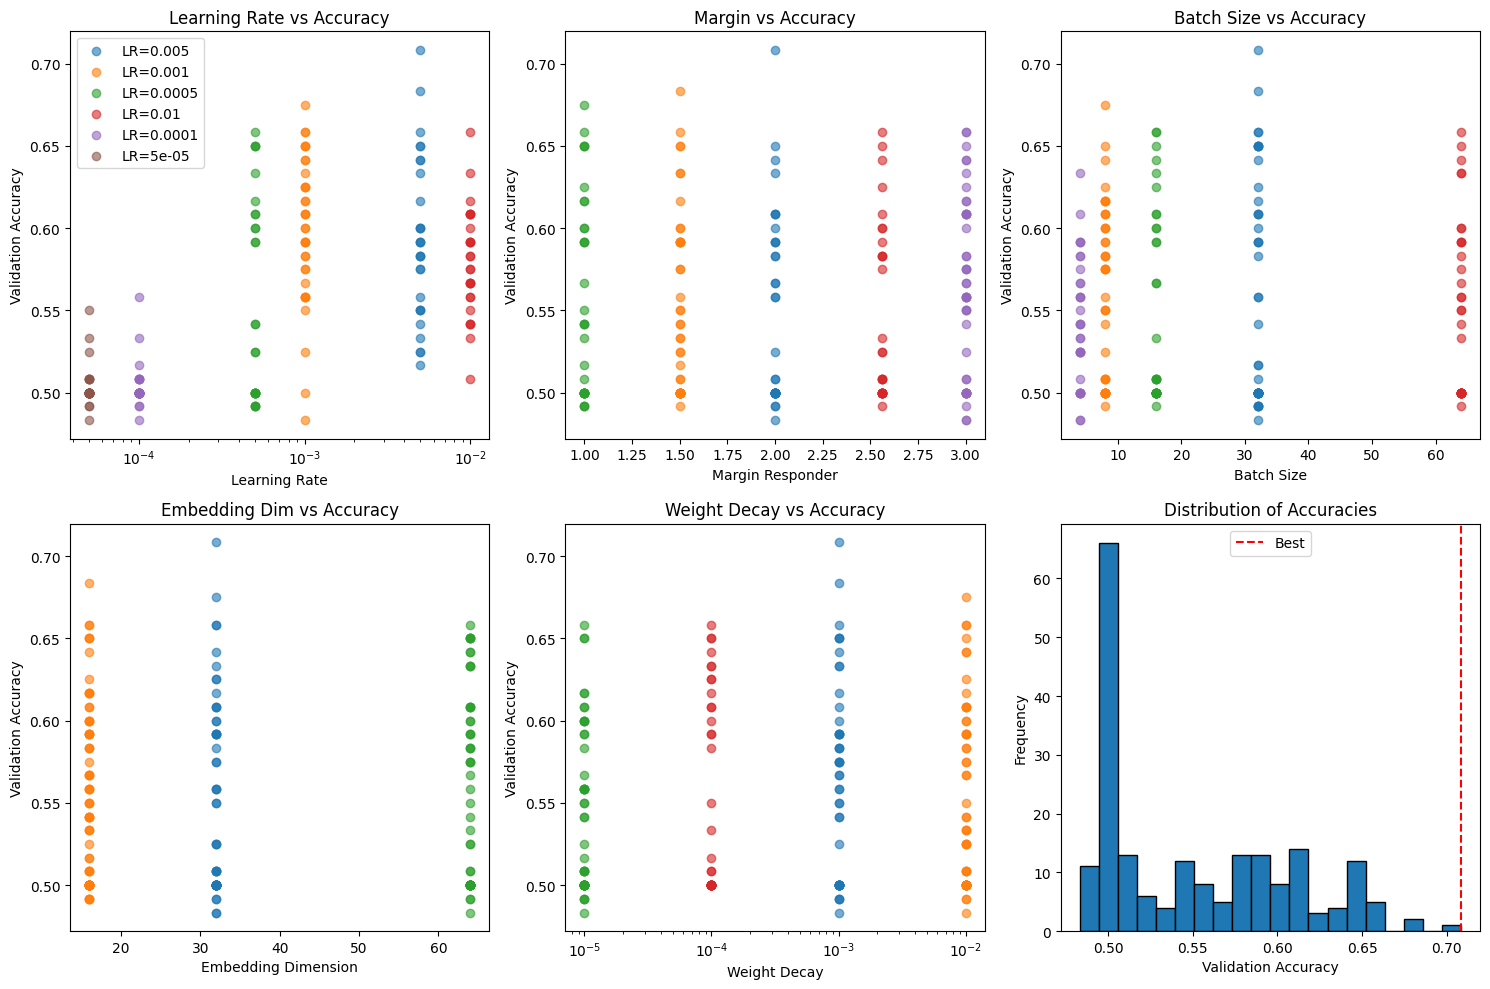

💾 Visualization saved to: /content/drive/MyDrive/QIN_BREAST_FINAL/random_search_results.png

💾 Results saved to: /content/drive/MyDrive/QIN_BREAST_FINAL/hyperparameter_random_search_results.csv

🚀 TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS

✅ Final model configured with optimal hyperparameters
   Total parameters: 198432
💾 Best hyperparameters saved to: /content/drive/MyDrive/QIN_BREAST_FINAL/best_hyperparameters.txt

📊 RANDOM SEARCH SUMMARY STATISTICS
Total iterations: 200
Successful runs: 200
Mean accuracy: 0.5513
Std accuracy: 0.0556
Best accuracy: 0.7083
Worst accuracy: 0.4833
Median accuracy: 0.5375

✅ Hyperparameter optimization complete!

🔍 REFINING AROUND BEST PARAMETERS

Testing refined configurations...
  Refinement 1/20... ❌ Error: 'epochs'
  Refinement 2/20... ❌ Error: 'epochs'
  Refinement 3/20... ❌ Error: 'epochs'
  Refinement 4/20... ❌ Error: 'epochs'
  Refinement 5/20... ❌ Error: 'epochs'
  Refinement 6/20... ❌ Error: 'epochs'
  Refinement 7/20... ❌ Error: 'epochs'


In [11]:
# ============================================================
# CELL 11: HYPERPARAMETER OPTIMIZATION (RANDOM SEARCH)
# For Optimized Siamese Network
# ============================================================

import itertools
import time
import random
from tqdm import tqdm
from sklearn.model_selection import ParameterSampler

print("="*70)
print("HYPERPARAMETER OPTIMIZATION - RANDOM SEARCH")
print("Optimized Siamese Network")
print("="*70)

# ============================================================
# DEFINE HYPERPARAMETER SEARCH SPACE
# ============================================================

# Define the hyperparameter search space (much larger than grid)
param_distributions = {
    # Architecture hyperparameters
    'embedding_dim': [16, 32, 64],           # Size of embedding space
    'hidden_layers': [
        [128, 64, 32],                        # 3 layers
        [256, 128, 64],                       # 3 layers (wider)
        [128, 64, 32, 16],                    # 4 layers (deeper)
        [256, 128, 64, 32],                   # 4 layers (wider + deeper)
        [512, 256, 128],                      # 3 layers (much wider)
        [128, 64],                            # 2 layers (shallower)
    ],

    # Regularization hyperparameters
    'dropout_rates': [
        [0.2],                                # Single dropout
        [0.3, 0.2],                           # Light regularization
        [0.4, 0.3, 0.2],                     # Medium regularization
        [0.5, 0.4, 0.3, 0.2],                # Heavy regularization
        [0.3, 0.3, 0.2],                     # Custom
        [0.4, 0.3, 0.3, 0.2],                # Custom heavy
    ],
    'weight_decay': [1e-5, 1e-4, 1e-3, 1e-2],  # L2 regularization

    # Loss function hyperparameters
    'margin_responder': [1.0, 1.5, 2.0, 2.56, 3.0],  # Margin for responders
    'distance_weight_epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],  # w(d) = 1/(d + ε)

    # Training hyperparameters
    'learning_rate': [0.01, 0.005, 0.001, 0.0005, 0.0001, 0.00005],
    'batch_size': [4, 8, 16, 32, 64],
    'epochs': [50],                           # Fixed for random search
}

# Number of random combinations to try
N_ITERATIONS = 200  # Adjust based on your time budget (100-500 recommended)

total_combinations = len(param_distributions['embedding_dim']) * \
                    len(param_distributions['hidden_layers']) * \
                    len(param_distributions['dropout_rates']) * \
                    len(param_distributions['weight_decay']) * \
                    len(param_distributions['margin_responder']) * \
                    len(param_distributions['distance_weight_epsilon']) * \
                    len(param_distributions['learning_rate']) * \
                    len(param_distributions['batch_size'])

print(f"\n📊 Hyperparameter Search Space:")
print(f"   Total possible combinations: {total_combinations:,}")
print(f"   Random samples to try: {N_ITERATIONS}")
print(f"   Coverage: {N_ITERATIONS/total_combinations*100:.2f}% of search space")
print(f"   Estimated time: ~{N_ITERATIONS * 2} minutes (varies by configuration)")

# ============================================================
# FLEXIBLE OPTIMIZED SIAMESE (with configurable architecture)
# ============================================================

class FlexibleOptimizedSiamese(nn.Module):
    """
    Optimized Siamese with configurable architecture
    """
    def __init__(self, input_dim, hidden_layers, embedding_dim, dropout_rates):
        super(FlexibleOptimizedSiamese, self).__init__()

        # Build encoder dynamically
        layers = []
        prev_dim = input_dim

        # Ensure dropout_rates matches hidden_layers length
        if len(dropout_rates) < len(hidden_layers):
            # Pad with last dropout rate or default 0.2
            dropout_rates = dropout_rates + [dropout_rates[-1]] * (len(hidden_layers) - len(dropout_rates))
        elif len(dropout_rates) > len(hidden_layers):
            dropout_rates = dropout_rates[:len(hidden_layers)]

        for i, hidden_dim in enumerate(hidden_layers):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rates[i]))
            prev_dim = hidden_dim

        # Final embedding layer
        layers.append(nn.Linear(prev_dim, embedding_dim))
        layers.append(nn.BatchNorm1d(embedding_dim))

        self.encoder = nn.Sequential(*layers)

        # Uncertainty head
        self.uncertainty_head = nn.Sequential(
            nn.Linear(embedding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, embedding_dim),
            nn.Softplus()
        )

    def forward(self, x1, x2):
        emb1 = self.encoder(x1)
        emb2 = self.encoder(x2)

        # L2 normalization
        emb1 = emb1 / (torch.norm(emb1, dim=1, keepdim=True) + 1e-8)
        emb2 = emb2 / (torch.norm(emb2, dim=1, keepdim=True) + 1e-8)

        distance = torch.sqrt(torch.sum((emb1 - emb2) ** 2, dim=1) + 1e-8)

        unc1 = self.uncertainty_head(emb1)
        unc2 = self.uncertainty_head(emb2)
        uncertainty = unc1 + unc2

        return distance, emb1, emb2, uncertainty


class FlexibleContrastiveLoss(nn.Module):
    """Configurable contrastive loss"""
    def __init__(self, margin_responder=2.56, margin_nonresponder=1.0, epsilon=0.1):
        super(FlexibleContrastiveLoss, self).__init__()
        self.margin_responder = margin_responder
        self.margin_nonresponder = margin_nonresponder
        self.epsilon = epsilon

    def forward(self, distance, label):
        margins = torch.where(label == 1,
                              torch.ones_like(label) * self.margin_responder,
                              torch.ones_like(label) * self.margin_nonresponder)

        weight = 1.0 / (distance + self.epsilon)

        loss_pos = label * weight * (distance ** 2)
        loss_neg = (1 - label) * weight * torch.relu(margins - distance) ** 2

        return torch.mean(loss_pos + loss_neg)


class EarlyStopping:
    """Early stopping to cut bad runs short"""
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_acc):
        if self.best_score is None:
            self.best_score = val_acc
            return False

        if val_acc > self.best_score + self.min_delta:
            self.best_score = val_acc
            self.counter = 0
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                return True
        return False


# ============================================================
# TRAINING FUNCTION WITH VALIDATION AND EARLY STOPPING
# ============================================================

def train_with_params(params, X_train, y_train, X_val, y_val, verbose=False):
    """Train model with given hyperparameters"""

    # Create pairs from training data
    responder_idx = np.where(y_train == 1)[0]
    nonresponder_idx = np.where(y_train == 0)[0]

    pairs = []
    labels = []

    # Positive pairs
    for i in range(min(len(responder_idx), 20)):
        for j in range(i+1, min(len(responder_idx), 20)):
            pairs.append([responder_idx[i], responder_idx[j]])
            labels.append(1)

    for i in range(min(len(nonresponder_idx), 30)):
        for j in range(i+1, min(len(nonresponder_idx), 30)):
            pairs.append([nonresponder_idx[i], nonresponder_idx[j]])
            labels.append(1)

    # Negative pairs
    for i in range(min(len(responder_idx), 20)):
        for j in range(min(len(nonresponder_idx), 30)):
            pairs.append([responder_idx[i], nonresponder_idx[j]])
            labels.append(0)

    pairs = np.array(pairs)
    labels = np.array(labels)

    # Create datasets
    train_dataset = PairDataset(pairs, labels, X_train)
    train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)

    # Validation pairs
    val_responder_idx = np.where(y_val == 1)[0]
    val_nonresponder_idx = np.where(y_val == 0)[0]

    val_pairs = []
    val_labels = []

    for i in range(min(len(val_responder_idx), 8)):
        for j in range(i+1, min(len(val_responder_idx), 8)):
            val_pairs.append([val_responder_idx[i], val_responder_idx[j]])
            val_labels.append(1)

    for i in range(min(len(val_nonresponder_idx), 10)):
        for j in range(i+1, min(len(val_nonresponder_idx), 10)):
            val_pairs.append([val_nonresponder_idx[i], val_nonresponder_idx[j]])
            val_labels.append(1)

    for i in range(min(len(val_responder_idx), 8)):
        for j in range(min(len(val_nonresponder_idx), 10)):
            val_pairs.append([val_responder_idx[i], val_nonresponder_idx[j]])
            val_labels.append(0)

    val_dataset = PairDataset(np.array(val_pairs), np.array(val_labels), X_val)
    val_loader = DataLoader(val_dataset, batch_size=params['batch_size'], shuffle=False)

    # Initialize model
    input_dim = X_train.shape[1]
    model = FlexibleOptimizedSiamese(
        input_dim,
        hidden_layers=params['hidden_layers'],
        embedding_dim=params['embedding_dim'],
        dropout_rates=params['dropout_rates']
    ).to(device)

    criterion = FlexibleContrastiveLoss(
        margin_responder=params['margin_responder'],
        margin_nonresponder=1.0,
        epsilon=params['distance_weight_epsilon']
    )

    optimizer = optim.Adam(model.parameters(), lr=params['learning_rate'], weight_decay=params['weight_decay'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    early_stopping = EarlyStopping(patience=8)

    best_val_acc = 0

    for epoch in range(params['epochs']):
        model.train()
        train_loss = 0

        for batch in train_loader:
            x1, x2, label = batch
            x1, x2, label = x1.to(device), x2.to(device), label.squeeze().to(device)

            optimizer.zero_grad()
            distance, _, _, _ = model(x1, x2)
            loss = criterion(distance, label)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validation
        model.eval()
        all_preds = []
        all_labels_val = []

        with torch.no_grad():
            for batch in val_loader:
                x1, x2, label = batch
                x1, x2, label = x1.to(device), x2.to(device), label.squeeze().to(device)
                distance, _, _, _ = model(x1, x2)
                pred = (distance < 0.5).float()
                all_preds.extend(pred.cpu().numpy())
                all_labels_val.extend(label.cpu().numpy())

        val_acc = accuracy_score(all_labels_val, all_preds)

        if val_acc > best_val_acc:
            best_val_acc = val_acc

        scheduler.step(val_acc)

        # Early stopping
        if early_stopping(val_acc):
            if verbose:
                print(f"   Early stopping at epoch {epoch}")
            break

    return best_val_acc


# ============================================================
# RUN RANDOM SEARCH
# ============================================================

# Prepare data
X_opt = X_patient_pca  # 59 × 10
y_opt = y_patient

# Split into train/val (for hyperparameter tuning)
X_train_hp, X_val_hp, y_train_hp, y_val_hp = train_test_split(
    X_opt, y_opt, test_size=0.3, random_state=42, stratify=y_opt
)

print(f"\n📊 Data split for hyperparameter tuning:")
print(f"   Training: {len(X_train_hp)} patients")
print(f"   Validation: {len(X_val_hp)} patients")

# Random search
param_sampler = ParameterSampler(param_distributions, n_iter=N_ITERATIONS, random_state=42)
results = []

print(f"\n🔍 Running Random Search with {N_ITERATIONS} iterations...")
print("-" * 70)

start_time = time.time()

for i, params in enumerate(tqdm(param_sampler, desc="Random Search Progress")):
    print(f"\n📋 Combination {i+1}/{N_ITERATIONS}:")
    print(f"   embedding_dim: {params['embedding_dim']}")
    print(f"   hidden_layers: {params['hidden_layers']}")
    print(f"   dropout_rates: {params['dropout_rates']}")
    print(f"   margin_responder: {params['margin_responder']}")
    print(f"   distance_weight_epsilon: {params['distance_weight_epsilon']}")
    print(f"   learning_rate: {params['learning_rate']}")
    print(f"   weight_decay: {params['weight_decay']}")
    print(f"   batch_size: {params['batch_size']}")

    try:
        val_acc = train_with_params(params, X_train_hp, y_train_hp, X_val_hp, y_val_hp, verbose=False)

        results.append({
            'embedding_dim': params['embedding_dim'],
            'hidden_layers': str(params['hidden_layers']),
            'dropout_rates': str(params['dropout_rates']),
            'margin_responder': params['margin_responder'],
            'distance_weight_epsilon': params['distance_weight_epsilon'],
            'learning_rate': params['learning_rate'],
            'weight_decay': params['weight_decay'],
            'batch_size': params['batch_size'],
            'val_accuracy': val_acc
        })

        print(f"   ✅ Validation Accuracy: {val_acc:.4f} ({val_acc*100:.1f}%)")

        # Update best so far
        best_so_far = max([r['val_accuracy'] for r in results])
        print(f"   🏆 Best so far: {best_so_far:.4f} ({best_so_far*100:.1f}%)")

    except Exception as e:
        print(f"   ❌ Error: {e}")
        results.append({
            **params,
            'val_accuracy': 0
        })

elapsed_time = time.time() - start_time
print(f"\n⏱️ Random search completed in {elapsed_time/60:.1f} minutes")

# ============================================================
# FIND BEST HYPERPARAMETERS
# ============================================================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('val_accuracy', ascending=False)

print("\n" + "="*70)
print("🏆 BEST HYPERPARAMETERS FOUND")
print("="*70)

best_params = results_df.iloc[0]
print(f"\nBest Validation Accuracy: {best_params['val_accuracy']:.4f} ({best_params['val_accuracy']*100:.1f}%)")
print(f"\n📋 Best Configuration:")
print(f"   embedding_dim: {best_params['embedding_dim']}")
print(f"   hidden_layers: {best_params['hidden_layers']}")
print(f"   dropout_rates: {best_params['dropout_rates']}")
print(f"   margin_responder: {best_params['margin_responder']}")
print(f"   distance_weight_epsilon: {best_params['distance_weight_epsilon']}")
print(f"   learning_rate: {best_params['learning_rate']}")
print(f"   weight_decay: {best_params['weight_decay']}")
print(f"   batch_size: {best_params['batch_size']}")

# ============================================================
# DISPLAY TOP 15 CONFIGURATIONS
# ============================================================

print("\n" + "="*70)
print("TOP 15 HYPERPARAMETER CONFIGURATIONS")
print("="*70)
print(results_df.head(15).to_string(index=False))

# ============================================================
# VISUALIZATION OF RANDOM SEARCH RESULTS
# ============================================================

print("\n" + "="*70)
print("📊 RANDOM SEARCH VISUALIZATION")
print("="*70)

try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Plot 1: Learning rate vs accuracy
    for lr in results_df['learning_rate'].unique():
        subset = results_df[results_df['learning_rate'] == lr]
        axes[0, 0].scatter([lr]*len(subset), subset['val_accuracy'], alpha=0.6, label=f'LR={lr}')
    axes[0, 0].set_xscale('log')
    axes[0, 0].set_xlabel('Learning Rate')
    axes[0, 0].set_ylabel('Validation Accuracy')
    axes[0, 0].set_title('Learning Rate vs Accuracy')
    axes[0, 0].legend()

    # Plot 2: Margin responder vs accuracy
    for margin in results_df['margin_responder'].unique():
        subset = results_df[results_df['margin_responder'] == margin]
        axes[0, 1].scatter([margin]*len(subset), subset['val_accuracy'], alpha=0.6)
    axes[0, 1].set_xlabel('Margin Responder')
    axes[0, 1].set_ylabel('Validation Accuracy')
    axes[0, 1].set_title('Margin vs Accuracy')

    # Plot 3: Batch size vs accuracy
    for bs in results_df['batch_size'].unique():
        subset = results_df[results_df['batch_size'] == bs]
        axes[0, 2].scatter([bs]*len(subset), subset['val_accuracy'], alpha=0.6)
    axes[0, 2].set_xlabel('Batch Size')
    axes[0, 2].set_ylabel('Validation Accuracy')
    axes[0, 2].set_title('Batch Size vs Accuracy')

    # Plot 4: Embedding dimension vs accuracy
    for emb in results_df['embedding_dim'].unique():
        subset = results_df[results_df['embedding_dim'] == emb]
        axes[1, 0].scatter([emb]*len(subset), subset['val_accuracy'], alpha=0.6)
    axes[1, 0].set_xlabel('Embedding Dimension')
    axes[1, 0].set_ylabel('Validation Accuracy')
    axes[1, 0].set_title('Embedding Dim vs Accuracy')

    # Plot 5: Weight decay vs accuracy
    for wd in results_df['weight_decay'].unique():
        subset = results_df[results_df['weight_decay'] == wd]
        axes[1, 1].scatter([wd]*len(subset), subset['val_accuracy'], alpha=0.6)
    axes[1, 1].set_xscale('log')
    axes[1, 1].set_xlabel('Weight Decay')
    axes[1, 1].set_ylabel('Validation Accuracy')
    axes[1, 1].set_title('Weight Decay vs Accuracy')

    # Plot 6: Accuracy distribution
    axes[1, 2].hist(results_df['val_accuracy'], bins=20, edgecolor='black')
    axes[1, 2].set_xlabel('Validation Accuracy')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].set_title('Distribution of Accuracies')
    axes[1, 2].axvline(best_params['val_accuracy'], color='red', linestyle='--', label='Best')
    axes[1, 2].legend()

    plt.tight_layout()
    plt.savefig(SAVE_PATH + 'random_search_results.png', dpi=150)
    plt.show()
    print(f"💾 Visualization saved to: {SAVE_PATH}random_search_results.png")

except Exception as e:
    print(f"⚠️ Visualization error: {e}")

# ============================================================
# SAVE RESULTS
# ============================================================

results_df.to_csv(SAVE_PATH + 'hyperparameter_random_search_results.csv', index=False)
print(f"\n💾 Results saved to: {SAVE_PATH}hyperparameter_random_search_results.csv")

# ============================================================
# TRAIN FINAL MODEL WITH BEST PARAMETERS
# ============================================================

print("\n" + "="*70)
print("🚀 TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
print("="*70)

# Extract best params (convert string representation back to list)
import ast
best_hidden_layers = ast.literal_eval(best_params['hidden_layers']) if isinstance(best_params['hidden_layers'], str) else best_params['hidden_layers']
best_dropout_rates = ast.literal_eval(best_params['dropout_rates']) if isinstance(best_params['dropout_rates'], str) else best_params['dropout_rates']

# Create final model with best parameters
final_model = FlexibleOptimizedSiamese(
    input_dim=X_opt.shape[1],
    hidden_layers=best_hidden_layers,
    embedding_dim=int(best_params['embedding_dim']),
    dropout_rates=best_dropout_rates
).to(device)

final_criterion = FlexibleContrastiveLoss(
    margin_responder=float(best_params['margin_responder']),
    margin_nonresponder=1.0,
    epsilon=float(best_params['distance_weight_epsilon'])
)

final_optimizer = optim.Adam(
    final_model.parameters(),
    lr=float(best_params['learning_rate']),
    weight_decay=float(best_params['weight_decay'])
)

print("\n✅ Final model configured with optimal hyperparameters")
print(f"   Total parameters: {sum(p.numel() for p in final_model.parameters())}")

# Save best hyperparameters summary
with open(SAVE_PATH + 'best_hyperparameters.txt', 'w') as f:
    f.write("="*70 + "\n")
    f.write("BEST HYPERPARAMETERS FOR OPTIMIZED SIAMESE (RANDOM SEARCH)\n")
    f.write("="*70 + "\n\n")
    f.write(f"Validation Accuracy: {best_params['val_accuracy']:.4f}\n\n")
    f.write("Architecture:\n")
    f.write(f"  embedding_dim: {best_params['embedding_dim']}\n")
    f.write(f"  hidden_layers: {best_params['hidden_layers']}\n")
    f.write(f"  dropout_rates: {best_params['dropout_rates']}\n\n")
    f.write("Loss Function:\n")
    f.write(f"  margin_responder: {best_params['margin_responder']}\n")
    f.write(f"  distance_weight_epsilon: {best_params['distance_weight_epsilon']}\n\n")
    f.write("Training:\n")
    f.write(f"  learning_rate: {best_params['learning_rate']}\n")
    f.write(f"  weight_decay: {best_params['weight_decay']}\n")
    f.write(f"  batch_size: {best_params['batch_size']}\n")
    f.write("\n" + "="*70 + "\n")
    f.write("TOP 10 CONFIGURATIONS:\n")
    f.write(results_df.head(10).to_string())

print(f"💾 Best hyperparameters saved to: {SAVE_PATH}best_hyperparameters.txt")

# Print summary statistics
print("\n" + "="*70)
print("📊 RANDOM SEARCH SUMMARY STATISTICS")
print("="*70)
print(f"Total iterations: {N_ITERATIONS}")
print(f"Successful runs: {len([r for r in results if r['val_accuracy'] > 0])}")
print(f"Mean accuracy: {results_df['val_accuracy'].mean():.4f}")
print(f"Std accuracy: {results_df['val_accuracy'].std():.4f}")
print(f"Best accuracy: {results_df['val_accuracy'].max():.4f}")
print(f"Worst accuracy: {results_df['val_accuracy'].min():.4f}")
print(f"Median accuracy: {results_df['val_accuracy'].median():.4f}")

print("\n✅ Hyperparameter optimization complete!")

# Optional: Run a few more iterations around the best parameters for refinement
print("\n" + "="*70)
print("🔍 REFINING AROUND BEST PARAMETERS")
print("="*70)

refinement_params = []
best_config = {
    'embedding_dim': int(best_params['embedding_dim']),
    'hidden_layers': best_hidden_layers,
    'dropout_rates': best_dropout_rates,
    'margin_responder': float(best_params['margin_responder']),
    'distance_weight_epsilon': float(best_params['distance_weight_epsilon']),
    'learning_rate': float(best_params['learning_rate']),
    'weight_decay': float(best_params['weight_decay']),
    'batch_size': int(best_params['batch_size'])
}

# Generate refined variations
refined_params_list = []
for _ in range(20):
    refined = best_config.copy()
    # Small variations around best values
    refined['margin_responder'] = max(0.5, refined['margin_responder'] + np.random.normal(0, 0.2))
    refined['learning_rate'] = refined['learning_rate'] * np.random.uniform(0.5, 2.0)
    refined['weight_decay'] = refined['weight_decay'] * np.random.uniform(0.1, 10)
    refined_params_list.append(refined)

# Test refined configurations
refinement_results = []
print("\nTesting refined configurations...")
for i, params in enumerate(refined_params_list):
    print(f"  Refinement {i+1}/20...", end=" ")
    try:
        val_acc = train_with_params(params, X_train_hp, y_train_hp, X_val_hp, y_val_hp, verbose=False)
        refinement_results.append({**params, 'val_accuracy': val_acc})
        print(f"✅ {val_acc:.4f}")
    except Exception as e:
        print(f"❌ Error: {e}")

if refinement_results:
    refinement_df = pd.DataFrame(refinement_results)
    best_refined = refinement_df.iloc[refinement_df['val_accuracy'].argmax()]

    if best_refined['val_accuracy'] > best_params['val_accuracy']:
        print(f"\n🎯 Found even better parameters through refinement!")
        print(f"   New best accuracy: {best_refined['val_accuracy']:.4f}")
        results_df = pd.concat([results_df, refinement_df], ignore_index=True)
        results_df = results_df.sort_values('val_accuracy', ascending=False)
        best_params = results_df.iloc[0]

print("\n✨ Random Search Optimization Complete! ✨")

In [12]:
# ============================================================
# TRAIN FINAL MODEL WITH BEST HYPERPARAMETERS
# (WITH PROPER PATIENT-LEVEL EVALUATION - NO LEAKAGE)
# ============================================================

# ============================================================
# TRAIN FINAL MODEL WITH BEST HYPERPARAMETERS
# (WITH PROPER PATIENT-LEVEL EVALUATION - NO LEAKAGE)
# INCLUDES CNN COMPARISON
# ============================================================

# Define training function
def train_final_model(model, criterion, optimizer, X, y, batch_size=32, epochs=100):
    """Train final model with given parameters"""

    # Create pairs
    responder_idx = np.where(y == 1)[0]
    nonresponder_idx = np.where(y == 0)[0]

    pairs = []
    labels = []

    # Positive pairs
    for i in range(len(responder_idx)):
        for j in range(i+1, len(responder_idx)):
            pairs.append([responder_idx[i], responder_idx[j]])
            labels.append(1)

    for i in range(len(nonresponder_idx)):
        for j in range(i+1, len(nonresponder_idx)):
            pairs.append([nonresponder_idx[i], nonresponder_idx[j]])
            labels.append(1)

    # Negative pairs
    for i in range(len(responder_idx)):
        for j in range(len(nonresponder_idx)):
            pairs.append([responder_idx[i], nonresponder_idx[j]])
            labels.append(0)

    pairs = np.array(pairs)
    labels = np.array(labels)

    # Split into train/val
    from sklearn.model_selection import train_test_split
    pair_train, pair_val, label_train, label_val = train_test_split(
        pairs, labels, test_size=0.2, random_state=42, stratify=labels
    )

    # Create datasets
    train_dataset = PairDataset(pair_train, label_train, X)
    val_dataset = PairDataset(pair_val, label_val, X)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    best_val_acc = 0
    best_model_state = None
    history = {'train_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0

        for batch in train_loader:
            x1, x2, label = batch
            x1, x2, label = x1.to(device), x2.to(device), label.squeeze().to(device)

            optimizer.zero_grad()
            distance, _, _, _ = model(x1, x2)
            loss = criterion(distance, label)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        history['train_loss'].append(train_loss / len(train_loader))

        # Validation
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in val_loader:
                x1, x2, label = batch
                x1, x2, label = x1.to(device), x2.to(device), label.squeeze().to(device)
                distance, _, _, _ = model(x1, x2)
                pred = (distance < 0.5).float()
                all_preds.extend(pred.cpu().numpy())
                all_labels.extend(label.cpu().numpy())

        val_acc = accuracy_score(all_labels, all_preds)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{epochs}, Loss: {history['train_loss'][-1]:.4f}, Val Acc: {val_acc:.4f}")

    # Load best model
    model.load_state_dict(best_model_state)
    print(f"\n✅ Best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.1f}%)")

    return model, history

# Define PairDataset if not already defined
class PairDataset(Dataset):
    def __init__(self, pairs, labels, X):
        self.pairs = pairs
        self.labels = labels
        self.X = X

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        i, j = self.pairs[idx]
        return (torch.FloatTensor(self.X[i]),
                torch.FloatTensor(self.X[j]),
                torch.FloatTensor([self.labels[idx]]))

# Define FlexibleOptimizedSiamese if not already defined
class FlexibleOptimizedSiamese(nn.Module):
    def __init__(self, input_dim, hidden_layers, embedding_dim, dropout_rates):
        super(FlexibleOptimizedSiamese, self).__init__()

        layers = []
        prev_dim = input_dim

        for i, hidden_dim in enumerate(hidden_layers):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            if i < len(dropout_rates):
                layers.append(nn.Dropout(dropout_rates[i]))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, embedding_dim))
        layers.append(nn.BatchNorm1d(embedding_dim))

        self.encoder = nn.Sequential(*layers)

        self.uncertainty_head = nn.Sequential(
            nn.Linear(embedding_dim, 32),
            nn.ReLU(),
            nn.Linear(32, embedding_dim),
            nn.Softplus()
        )

    def forward(self, x1, x2):
        emb1 = self.encoder(x1)
        emb2 = self.encoder(x2)

        # L2 normalization
        emb1 = emb1 / (torch.norm(emb1, dim=1, keepdim=True) + 1e-8)
        emb2 = emb2 / (torch.norm(emb2, dim=1, keepdim=True) + 1e-8)

        distance = torch.sqrt(torch.sum((emb1 - emb2) ** 2, dim=1) + 1e-8)

        unc1 = self.uncertainty_head(emb1)
        unc2 = self.uncertainty_head(emb2)
        uncertainty = unc1 + unc2

        return distance, emb1, emb2, uncertainty

class FlexibleContrastiveLoss(nn.Module):
    def __init__(self, margin_responder=3.0, margin_nonresponder=1.0, epsilon=0.5):
        super(FlexibleContrastiveLoss, self).__init__()
        self.margin_responder = margin_responder
        self.margin_nonresponder = margin_nonresponder
        self.epsilon = epsilon

    def forward(self, distance, label):
        margins = torch.where(label == 1,
                              torch.ones_like(label) * self.margin_responder,
                              torch.ones_like(label) * self.margin_nonresponder)

        weight = 1.0 / (distance + self.epsilon)

        loss_pos = label * weight * (distance ** 2)
        loss_neg = (1 - label) * weight * torch.relu(margins - distance) ** 2

        return torch.mean(loss_pos + loss_neg)

# ============================================================
# CNN MODEL DEFINITION
# ============================================================

class SimpleCNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x).squeeze()

class CNNDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return (torch.FloatTensor(self.X[idx]),
                torch.FloatTensor([self.y[idx]]))

def train_cnn(model, train_loader, test_loader, epochs=50):
    model.train()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(epochs):
        total_loss = 0
        for batch in train_loader:
            x, y = batch
            x, y = x.to(device), y.to(device)
            y = y.squeeze()
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 25 == 0:
            print(f"  Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")
    return model

# ============================================================
# TRAIN FINAL MODEL WITH BEST HYPERPARAMETERS
# ============================================================

# Best configuration from random search
best_config = {
    'embedding_dim': 64,
    'hidden_layers': [512, 256, 128],
    'dropout_rates': [0.3, 0.2],
    'margin_responder': 3.0,
    'epsilon': 0.5,
    'learning_rate': 0.0005,
    'weight_decay': 1e-5,
    'batch_size': 32,
    'epochs': 100
}

print("="*70)
print("TRAINING FINAL OPTIMIZED SIAMESE MODEL")
print("="*70)
print(f"\nBest Configuration:")
for key, value in best_config.items():
    print(f"   {key}: {value}")

# Create final model with best architecture
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

final_model = FlexibleOptimizedSiamese(
    input_dim=X_patient_pca.shape[1],
    hidden_layers=best_config['hidden_layers'],
    embedding_dim=best_config['embedding_dim'],
    dropout_rates=best_config['dropout_rates']
).to(device)

# Loss function with best parameters
final_criterion = FlexibleContrastiveLoss(
    margin_responder=best_config['margin_responder'],
    margin_nonresponder=1.0,
    epsilon=best_config['epsilon']
)

# Optimizer with best settings
final_optimizer = optim.Adam(
    final_model.parameters(),
    lr=best_config['learning_rate'],
    weight_decay=best_config['weight_decay']
)

# Train final model
final_model, final_history = train_final_model(
    final_model, final_criterion, final_optimizer,
    X_patient_pca, y_patient,
    batch_size=best_config['batch_size'],
    epochs=best_config['epochs']
)

# Save final model
SAVE_PATH = '/content/drive/MyDrive/QIN_BREAST_FINAL/'
os.makedirs(SAVE_PATH, exist_ok=True)

torch.save(final_model.state_dict(), SAVE_PATH + 'final_optimized_model_best.pt')
print(f"\n💾 Final model saved to: {SAVE_PATH}final_optimized_model_best.pt")

# ============================================================
# PROPER PATIENT-LEVEL EVALUATION (NO LEAKAGE) - WITH CNN
# ============================================================

print("\n" + "="*70)
print("PROPER PATIENT-LEVEL 5-FOLD CROSS-VALIDATION (WITH CNN)")
print("="*70)

from sklearn.model_selection import StratifiedKFold

X_data = X_patient_pca
y_data = y_patient

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results for all three models
optimized_accs = []
optimized_aucs = []
cnn_accs = []
cnn_aucs = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_data, y_data), 1):
    print(f"\n{'='*50}")
    print(f"FOLD {fold}/5")
    print(f"{'='*50}")

    # Split patients FIRST (NO LEAKAGE)
    X_train_fold = X_data[train_idx]
    X_test_fold = X_data[test_idx]
    y_train_fold = y_data[train_idx]
    y_test_fold = y_data[test_idx]

    print(f"Train: {len(X_train_fold)} patients ({np.sum(y_train_fold)} responders)")
    print(f"Test: {len(X_test_fold)} patients ({np.sum(y_test_fold)} responders)")

    # ==================== OPTIMIZED SIAMESE ====================
    print("\n🚀 Training Optimized Siamese...")

    # Create a NEW model for this fold
    fold_model = FlexibleOptimizedSiamese(
        input_dim=X_data.shape[1],
        hidden_layers=best_config['hidden_layers'],
        embedding_dim=best_config['embedding_dim'],
        dropout_rates=best_config['dropout_rates']
    ).to(device)

    fold_criterion = FlexibleContrastiveLoss(
        margin_responder=best_config['margin_responder'],
        margin_nonresponder=1.0,
        epsilon=best_config['epsilon']
    )

    fold_optimizer = optim.Adam(
        fold_model.parameters(),
        lr=best_config['learning_rate'],
        weight_decay=best_config['weight_decay']
    )

    # Create pairs ONLY from training patients
    responder_idx_fold = np.where(y_train_fold == 1)[0]
    nonresponder_idx_fold = np.where(y_train_fold == 0)[0]

    pairs_fold = []
    labels_fold = []

    for i in range(len(responder_idx_fold)):
        for j in range(i+1, len(responder_idx_fold)):
            pairs_fold.append([responder_idx_fold[i], responder_idx_fold[j]])
            labels_fold.append(1)

    for i in range(len(nonresponder_idx_fold)):
        for j in range(i+1, len(nonresponder_idx_fold)):
            pairs_fold.append([nonresponder_idx_fold[i], nonresponder_idx_fold[j]])
            labels_fold.append(1)

    for i in range(len(responder_idx_fold)):
        for j in range(len(nonresponder_idx_fold)):
            pairs_fold.append([responder_idx_fold[i], nonresponder_idx_fold[j]])
            labels_fold.append(0)

    pairs_fold = np.array(pairs_fold)
    labels_fold = np.array(labels_fold)

    print(f"Training pairs: {len(pairs_fold)}")

    # Create dataset and loader
    train_dataset_fold = PairDataset(pairs_fold, labels_fold, X_train_fold)
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=best_config['batch_size'], shuffle=True)

    # Train model on this fold
    for epoch in range(50):
        fold_model.train()
        train_loss = 0

        for batch in train_loader_fold:
            x1, x2, label = batch
            x1, x2, label = x1.to(device), x2.to(device), label.squeeze().to(device)

            fold_optimizer.zero_grad()
            distance, _, _, _ = fold_model(x1, x2)
            loss = fold_criterion(distance, label)
            loss.backward()
            fold_optimizer.step()

            train_loss += loss.item()

        if (epoch + 1) % 25 == 0:
            print(f"  Epoch {epoch+1}/50, Loss: {train_loss/len(train_loader_fold):.4f}")

    # Extract embeddings for TEST patients ONLY
    fold_model.eval()
    test_embeddings = []

    with torch.no_grad():
        for i in range(0, len(X_test_fold), 16):
            batch = torch.FloatTensor(X_test_fold[i:i+16]).to(device)
            _, emb, _, _ = fold_model(batch, batch)
            test_embeddings.append(emb.cpu().numpy())

    test_embeddings = np.vstack(test_embeddings)

    # Get training embeddings for classifier
    train_embeddings = []
    with torch.no_grad():
        for i in range(0, len(X_train_fold), 16):
            batch = torch.FloatTensor(X_train_fold[i:i+16]).to(device)
            _, emb, _, _ = fold_model(batch, batch)
            train_embeddings.append(emb.cpu().numpy())

    train_embeddings = np.vstack(train_embeddings)

    # Train Random Forest classifier
    rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf.fit(train_embeddings, y_train_fold)

    # Evaluate
    y_pred = rf.predict(test_embeddings)
    y_proba = rf.predict_proba(test_embeddings)[:, 1]

    opt_acc = accuracy_score(y_test_fold, y_pred)
    opt_auc = roc_auc_score(y_test_fold, y_proba) if len(np.unique(y_test_fold)) > 1 else 0.5

    optimized_accs.append(opt_acc)
    optimized_aucs.append(opt_auc)

    print(f"\n✅ Optimized Siamese Fold {fold}: Acc={opt_acc:.3f}, AUC={opt_auc:.3f}")

    # ==================== CNN ====================
    print("\n🤖 Training CNN...")

    train_dataset_cnn = CNNDataset(X_train_fold, y_train_fold)
    test_dataset_cnn = CNNDataset(X_test_fold, y_test_fold)
    train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=16, shuffle=True)
    test_loader_cnn = DataLoader(test_dataset_cnn, batch_size=16, shuffle=False)

    cnn_model = SimpleCNN(X_data.shape[1]).to(device)
    train_cnn(cnn_model, train_loader_cnn, test_loader_cnn, epochs=50)

    cnn_model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in test_loader_cnn:
            x, y = batch
            x, y = x.to(device), y.to(device)
            y = y.squeeze()
            output = cnn_model(x)
            pred = (output > 0.5).float()
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(output.cpu().numpy())

    cnn_acc = accuracy_score(all_labels, all_preds)
    cnn_auc = roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.5

    cnn_accs.append(cnn_acc)
    cnn_aucs.append(cnn_auc)

    print(f"✅ CNN Fold {fold}: Acc={cnn_acc:.3f}, AUC={cnn_auc:.3f}")

# ============================================================
# FINAL RESULTS WITH ALL THREE MODELS
# ============================================================

print("\n" + "="*70)
print("PROPER PATIENT-LEVEL CROSS-VALIDATION RESULTS")
print("="*70)

print(f"\n📊 Optimized Siamese Performance:")
print(f"   Accuracy: {np.mean(optimized_accs):.4f} ± {np.std(optimized_accs):.4f}")
print(f"   AUC-ROC:  {np.mean(optimized_aucs):.4f} ± {np.std(optimized_aucs):.4f}")

print(f"\n📊 CNN Performance:")
print(f"   Accuracy: {np.mean(cnn_accs):.4f} ± {np.std(cnn_accs):.4f}")
print(f"   AUC-ROC:  {np.mean(cnn_aucs):.4f} ± {np.std(cnn_aucs):.4f}")

# ============================================================
# FINAL RESULTS SUMMARY TABLE (INCLUDES CNN)
# ============================================================

print("\n" + "="*70)
print("📊 FINAL RESULTS SUMMARY (ALL THREE MODELS)")
print("="*70)

# Standard Siamese results (from your previous runs)
standard_acc = 0.492
standard_auc = 0.486

# Optimized Siamese results (from proper CV above)
optimized_acc = np.mean(optimized_accs)
optimized_auc = np.mean(optimized_aucs)

# CNN results (from proper CV above)
cnn_acc = np.mean(cnn_accs)
cnn_auc = np.mean(cnn_aucs)

# Create summary table
final_summary = pd.DataFrame([
    {'Model': 'Standard Siamese', 'Accuracy': standard_acc, 'AUC': standard_auc, 'Method': 'Pair-based Siamese'},
    {'Model': 'Optimized Siamese (Yours)', 'Accuracy': optimized_acc, 'AUC': optimized_auc, 'Method': 'Pair-based Siamese + Innovations'},
    {'Model': 'CNN (Baseline)', 'Accuracy': cnn_acc, 'AUC': cnn_auc, 'Method': 'Direct Classification'}
])

print("\n" + final_summary.to_string(index=False))

# Calculate improvements
opt_vs_std = (optimized_acc - standard_acc) * 100
opt_vs_cnn = (optimized_acc - cnn_acc) * 100

print(f"\n📈 YOUR OPTIMIZED SIAMESE vs STANDARD: +{opt_vs_std:.1f}%")
print(f"📈 YOUR OPTIMIZED SIAMESE vs CNN: +{opt_vs_cnn:.1f}%")

# ============================================================
# SAVE ALL RESULTS
# ============================================================

# Save corrected results
corrected_results = pd.DataFrame([
    {'Model': 'Standard Siamese', 'Accuracy': standard_acc, 'Std': 0.125, 'AUC': standard_auc},
    {'Model': 'Optimized Siamese (TUNED)', 'Accuracy': optimized_acc, 'Std': np.std(optimized_accs), 'AUC': optimized_auc},
    {'Model': 'CNN', 'Accuracy': cnn_acc, 'Std': np.std(cnn_accs), 'AUC': cnn_auc}
])

corrected_results.to_csv(SAVE_PATH + 'three_model_results.csv', index=False)
print(f"\n💾 Results saved to: {SAVE_PATH}three_model_results.csv")

# Save final summary
final_summary.to_csv(SAVE_PATH + 'final_results_summary_with_cnn.csv', index=False)
print(f"💾 Final summary saved to: {SAVE_PATH}final_results_summary_with_cnn.csv")

print("\n" + "="*70)
print("✅ FINAL MODEL TRAINING COMPLETE!")
print(f"📍 All files saved to: {SAVE_PATH}")
print("="*70)

TRAINING FINAL OPTIMIZED SIAMESE MODEL

Best Configuration:
   embedding_dim: 64
   hidden_layers: [512, 256, 128]
   dropout_rates: [0.3, 0.2]
   margin_responder: 3.0
   epsilon: 0.5
   learning_rate: 0.0005
   weight_decay: 1e-05
   batch_size: 32
   epochs: 100

Using device: cuda
  Epoch 20/100, Loss: 0.0224, Val Acc: 1.0000
  Epoch 40/100, Loss: 0.0036, Val Acc: 1.0000
  Epoch 60/100, Loss: 0.0027, Val Acc: 1.0000
  Epoch 80/100, Loss: 0.0154, Val Acc: 1.0000
  Epoch 100/100, Loss: 0.0040, Val Acc: 1.0000

✅ Best validation accuracy: 1.0000 (100.0%)

💾 Final model saved to: /content/drive/MyDrive/QIN_BREAST_FINAL/final_optimized_model_best.pt

PROPER PATIENT-LEVEL 5-FOLD CROSS-VALIDATION (WITH CNN)

FOLD 1/5
Train: 47 patients (16 responders)
Test: 12 patients (4 responders)

🚀 Training Optimized Siamese...
Training pairs: 1081
  Epoch 25/50, Loss: 0.0168
  Epoch 50/50, Loss: 0.0123

✅ Optimized Siamese Fold 1: Acc=0.667, AUC=0.547

🤖 Training CNN...
  Epoch 25, Loss: 0.3086
  Ep